In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Telco_customer_churn.xlsx")
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [58]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [59]:
df.shape

(7043, 33)

In [60]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [61]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


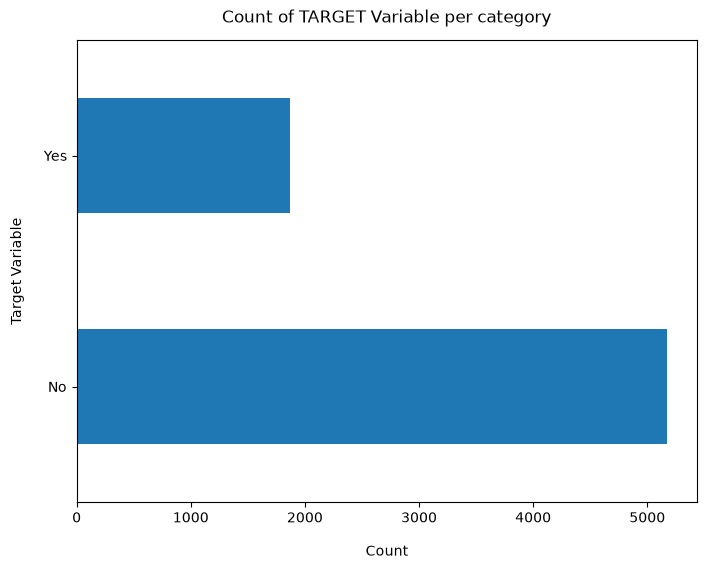

In [62]:
df['Churn Label'].value_counts().plot(kind='barh', figsize=(8, 6))
plt.xlabel("Count", labelpad=14)
plt.ylabel("Target Variable", labelpad=14)
plt.title("Count of TARGET Variable per category", y=1.02);

In [63]:
100*df['Churn Label'].value_counts()/len(df['Churn Label'])

Churn Label
No     73.463013
Yes    26.536987
Name: count, dtype: float64

In [64]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [65]:
df.info(verbose = True) 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

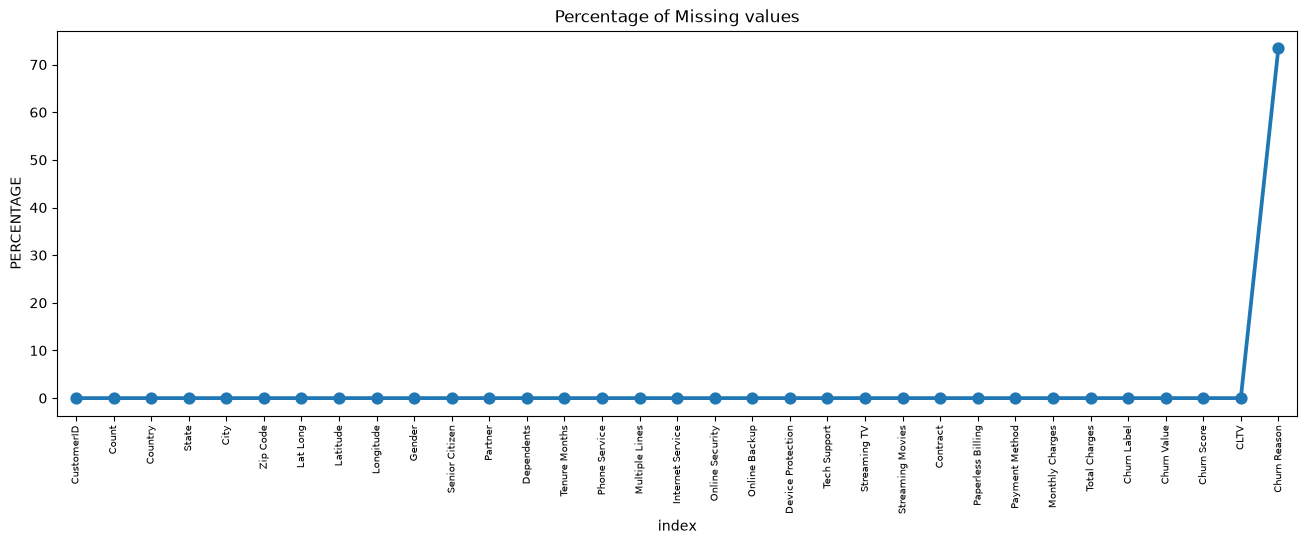

In [66]:
missing = pd.DataFrame(df.isnull().sum()*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index', y=0, data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

In [67]:
print("Missing values per column before cleaning:")
print(df.isnull().sum())
missing_cols = df.columns[df.isnull().any()].tolist()

if missing_cols:
    print(f"Found missing values in: {missing_cols}")
    
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    for col in num_cols:
        if col in missing_cols:
            df[col] = df[col].fillna(df[col].median())

    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if col in missing_cols:
            df[col] = df[col].fillna(df[col].mode()[0])
else:
    print("No other columns have missing values.")

print(df.isnull().sum())


Missing values per column before cleaning:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64
Found missing values in: ['Churn Reason']
CustomerID           0
Count                

/var/folders/pq/qd5nqhp11cn0sjjv9fn51c340000gn/T/ipykernel_53019/2430075630.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [68]:
print("Missing values per column AFTER cleaning:")
print(df.isnull().sum())

Missing values per column AFTER cleaning:
CustomerID           0
Count                0
Country              0
State                0
City                 0
Zip Code             0
Lat Long             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
Churn Value          0
Churn Score          0
CLTV                 0
Churn Reason         0
dtype: int64


In [69]:
print(f"Final dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Final dataset has 7043 rows and 33 columns.


In [70]:
print(df['Churn Label'].value_counts(normalize=True) * 100)

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

model_df = df.copy()


In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import joblib

model_df = df.copy()

cols_to_drop = ['CustomerID', 'Churn Label','Churn Score', 'Churn Reason']
model_df = model_df.drop(columns=cols_to_drop, errors='ignore')

cat_cols = model_df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    model_df[col] = model_df[col].astype(str)

X = model_df.drop('Churn Value', axis=1)
y = model_df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist() 

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, num_cols),('cat', cat_transformer, cat_cols)])
model = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

print("Training model...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n Model Trained Successfully!")
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print(f"\n--- AUC-ROC SCORE ---\n{auc:.4f}")

filename = 'churn_model.pkl'
joblib.dump(model, filename)
print(f"\nModel saved as '{filename}'. Add this file to your ZIP for submission.")

/var/folders/pq/qd5nqhp11cn0sjjv9fn51c340000gn/T/ipykernel_53019/3267677323.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = model_df.select_dtypes(include=['object']).columns.tolist()
/var/folders/pq/qd5nqhp11cn0sjjv9fn51c340000gn/T/ipykernel_53019/3267677323.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning

Training model...

 Model Trained Successfully!

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409

--- CONFUSION MATRIX ---
[[947  88]
 [195 179]]

--- AUC-ROC SCORE ---
0.8341

Model saved as 'churn_model.pkl'. Add this file to your ZIP for submission.


MODEL PERFORMANCE REPORT

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409


--- CONFUSION MATRIX ---
[[947  88]
 [195 179]]

--- AUC-ROC SCORE ---
0.8341 (0.5 = Random guess, 1.0 = Perfect prediction)


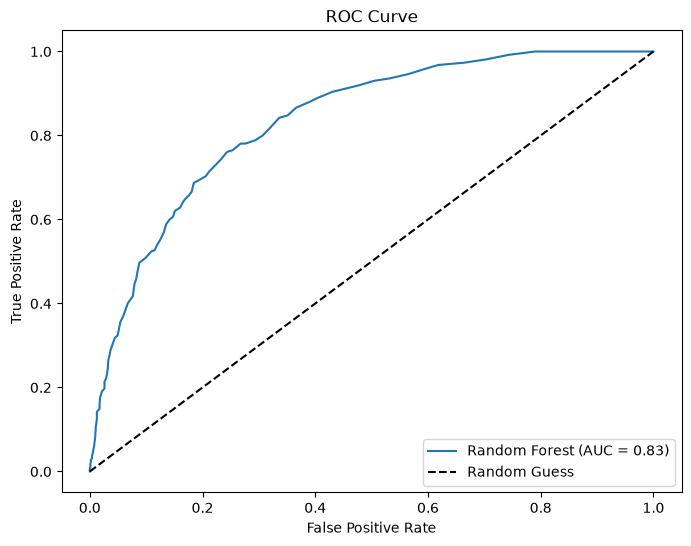

In [73]:
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

loaded_model = joblib.load('churn_model.pkl')

y_pred = loaded_model.predict(X_test)
y_proba = loaded_model.predict_proba(X_test)[:, 1]

print("="*50)
print("MODEL PERFORMANCE REPORT")
print("="*50)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))

auc_score = roc_auc_score(y_test, y_proba)
print(f"\n--- AUC-ROC SCORE ---")
print(f"{auc_score:.4f} (0.5 = Random guess, 1.0 = Perfect prediction)")

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [75]:
filename = 'churn_model.pkl'
joblib.dump(model, filename)
print(f"New honest model saved as '{filename}'. AUC is 0.8341.")

New honest model saved as 'churn_model.pkl'. AUC is 0.8341.
